# Assignment 2.1

Name:  Justin Nguyen
Date:  09/09/2026

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binom

## Problem # 2.1.

For the rain simulation example in Section 2.1.1, but with probability of rain 0.30 on any
given day, simulate the outcome (a) on the next day, (b) the next 10 days. (c) Simulate the
proportion of days of rain for the next (i) 100 days, (ii) 10,000 days, (iii) 1,000,000 days. Use
the simulation to explain the long-run relative frequency definition of probability.

`(a) Your answer goes here`

In [31]:
np.random.binomial(n=1, p=0.3, size=1)

array([1], dtype=int32)

`(b) Your answer goes here`

In [32]:
np.random.binomial(n=1, p=0.3, size=10)

array([0, 0, 1, 0, 1, 0, 1, 1, 0, 0], dtype=int32)

`(c) Your answer goes here`

In [33]:
print(np.random.binomial(n=1, p=0.3, size=100))
print(np.random.binomial(n=1, p=0.3, size=10000))
print(np.random.binomial(n=1, p=0.3, size=1000000))

[1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0
 1 0 1 0 0 0 0 1 0 0 1 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 1 0]


as n increases, the probability stabilizes and in this scenario the probability converges to 30%

## Problem # 2.2.

Data analysts often implement statistical inference methods by setting the probability of a
correct inference equal to 0.95. Let *A* denote the event that an inference for the population
about men is correct. Let *B* represent the event of a corresponding inference about women
being correct. Suppose that these are independent events.


(a) Find the probability that (i) *both* inferences are correct, (ii) *neither* inference is correct.  
(b) Construct the probability distribution for *Y* = number of correct inferences.  
(c) With what probability would each inference need to be correct in order for the probability to be 0.95 that *both* are correct?



`(a) Your answer goes here`

The multiplicative law of probability for independent events state that P(AB) = P(A)P(B) so we just multiply the probability that event A is correct (.95) and event B is correct (.95)

In [34]:
correct = .95
incorrect = 1 - correct
print(correct * correct)

0.9025


Same thing for the second part, we just multiply the probability that event A is incorrect (.05) and event B is incorrect (.05)

In [35]:
print(incorrect * incorrect)

0.0025000000000000044


`(b) Your answer goes here`

We use the probability mass function to find the probability distribution for discrete random variables

In [36]:
print(binom.pmf(0, n=2, p=.95))
print(binom.pmf(1, n=2, p=.95))
print(binom.pmf(2, n=2, p=.95))

0.002500000000000005
0.09500000000000008
0.9025


`(c) Your answer goes here`

P(AB) = P(A)P(B)
.95 = P(A)P(B)
.95 = (P(A))^2
So we can find the square root of .95 to get the probability that each inference would need to be to get a probability of .95 that both events are correct

In [37]:
print(np.sqrt(.95))

0.9746794344808963


The probability that each inference would need to be is ~.97.

## Problem # 2.4.

A wine connoisseur is asked to match five glasses of red wine with the bottles from which they
came, representing five different grape types.


(a) Set up a sample space for the five guesses.  
(b) With random guessing, find the probability of getting all five correct.

`(a) Your answer goes here`

My first instinct here was to set up a sample space of success/failure since we were not given the names of the types of grape but I asked claude and it said to use permutations. I also wanted to get the probability distribution of getting Y guesses correct where y=0, 1, 2, ..., 5 so to do that I'll first build a dataframe to hold ['trial_num', 'guess', 'num_correct']. Then I need to get .value_counts() to get a frequency distribution and for each number I'll divide that by the number of trials to get the probability of that number of guesses. After that I'll build another dataframe to hold ['y', 'p_dist_100', 'p_dist_10000', 'p_dist_1000000'].

I ended up changing the trial number from 100, 10000, 1000000 to 10, 100, 1000 because it was taking too long to run, I stopped it at 31 minutes.

In [38]:
from itertools import permutations

grapes = tuple(['A', 'B', 'C', 'D', 'E'])
sample_space = list(permutations(grapes))
simulations_10 = pd.DataFrame(columns=['trial_num', 'guess', 'num_correct'])
for trial in range(10):
    guess = np.random.choice(grapes, size=5, replace=False)
    num_correct = (guess == grapes).sum()
    simulations_10 = pd.concat([simulations_10, pd.DataFrame([{'trial_num': trial + 1, 'guess': guess, 'num_correct': num_correct}])], ignore_index=True)

p_y0_10 = (simulations_10['num_correct'] == 0).mean()
p_y1_10 = (simulations_10['num_correct'] == 1).mean()
p_y2_10 = (simulations_10['num_correct'] == 2).mean()
p_y3_10 = (simulations_10['num_correct'] == 3).mean()
p_y4_10 = (simulations_10['num_correct'] == 4).mean()
p_y5_10 = (simulations_10['num_correct'] == 5).mean()

simulations_100 = pd.DataFrame(columns=['trial_num', 'guess', 'num_correct'])
for trial in range(100):
    guess = np.random.choice(grapes, size=5, replace=False)
    num_correct = (guess == grapes).sum()
    simulations_100 = pd.concat([simulations_100, pd.DataFrame([{'trial_num': trial + 1, 'guess': guess, 'num_correct': num_correct}])], ignore_index=True)

p_y0_100 = (simulations_100['num_correct'] == 0).mean()
p_y1_100 = (simulations_100['num_correct'] == 1).mean()
p_y2_100 = (simulations_100['num_correct'] == 2).mean()
p_y3_100 = (simulations_100['num_correct'] == 3).mean()
p_y4_100 = (simulations_100['num_correct'] == 4).mean()
p_y5_100 = (simulations_100['num_correct'] == 5).mean()

simulations_1000 = pd.DataFrame(columns=['trial_num', 'guess', 'num_correct'])
for trial in range(1000):
    guess = np.random.choice(grapes, size=5, replace=False)
    num_correct = (guess == grapes).sum()
    simulations_1000 = pd.concat([simulations_1000, pd.DataFrame([{'trial_num': trial + 1, 'guess': guess, 'num_correct': num_correct}])], ignore_index=True)

p_y0_1000 = (simulations_1000['num_correct'] == 0).mean()
p_y1_1000 = (simulations_1000['num_correct'] == 1).mean()
p_y2_1000 = (simulations_1000['num_correct'] == 2).mean()
p_y3_1000 = (simulations_1000['num_correct'] == 3).mean()
p_y4_1000 = (simulations_1000['num_correct'] == 4).mean()
p_y5_1000 = (simulations_1000['num_correct'] == 5).mean()

simulations_10000 = pd.DataFrame(columns=['trial_num', 'guess', 'num_correct'])
for trial in range(10000):
    guess = np.random.choice(grapes, size=5, replace=False)
    num_correct = (guess == grapes).sum()
    simulations_10000 = pd.concat([simulations_10000, pd.DataFrame([{'trial_num': trial + 1, 'guess': guess, 'num_correct': num_correct}])], ignore_index=True)

p_y0_10000 = (simulations_10000['num_correct'] == 0).mean()
p_y1_10000 = (simulations_10000['num_correct'] == 1).mean()
p_y2_10000 = (simulations_10000['num_correct'] == 2).mean()
p_y3_10000 = (simulations_10000['num_correct'] == 3).mean()
p_y4_10000 = (simulations_10000['num_correct'] == 4).mean()
p_y5_10000 = (simulations_10000['num_correct'] == 5).mean()

p_dist_for_Y = pd.DataFrame(columns=['y', 'p_dist_10', 'p_dist_100', 'p_dist_1000', 'p_dist_10000'])
p_dist_for_Y = pd.DataFrame([
    {'y': 0, 'p_dist_10': p_y0_10, 'p_dist_100': p_y0_100, 'p_dist_1000': p_y0_1000, 'p_dist_10000': p_y0_10000},
    {'y': 1, 'p_dist_10': p_y1_10, 'p_dist_100': p_y1_100, 'p_dist_1000': p_y1_1000, 'p_dist_10000': p_y1_10000},
    {'y': 2, 'p_dist_10': p_y2_10, 'p_dist_100': p_y2_100, 'p_dist_1000': p_y2_1000, 'p_dist_10000': p_y2_10000},
    {'y': 3, 'p_dist_10': p_y3_10, 'p_dist_100': p_y3_100, 'p_dist_1000': p_y3_1000, 'p_dist_10000': p_y3_10000},
    {'y': 4, 'p_dist_10': p_y4_10, 'p_dist_100': p_y4_100, 'p_dist_1000': p_y4_1000, 'p_dist_10000': p_y4_10000},
    {'y': 5, 'p_dist_10': p_y5_10, 'p_dist_100': p_y5_100, 'p_dist_1000': p_y5_1000, 'p_dist_10000': p_y5_10000}
])

print(p_dist_for_Y)

   y  p_dist_10  p_dist_100  p_dist_1000  p_dist_10000
0  0        0.1        0.42        0.394        0.3660
1  1        0.5        0.42        0.374        0.3762
2  2        0.2        0.12        0.145        0.1641
3  3        0.2        0.04        0.082        0.0850
4  4        0.0        0.00        0.000        0.0000
5  5        0.0        0.00        0.005        0.0087


In [39]:
print(len(sample_space))

120


`(b) Your answer goes here`

The probablity of all 5 being correct is 1/120 which is roughly .0083 and the simulation above correctly displays that. 

## Problem # 2.15.

Each week an insurance company records *Y* = number of payments because of a home burning
down. State conditions under which we would expect *Y* to approximately have a Poisson
distribution.


`Your answer goes here`

We have a time window and the probability of a home burning down is quite small without taking into account any other factors such as weather, state, dryness of grass

Above was my original answer from what I understood from the textbook. After consulting with Claude I found that I forgot about 1/3 important conditions for the Poisson distribution.

1. Each window needs to be independent of each other (this is the one I forgot about)
2. There needs to be a constant average rate over time so what I said about weather and dryness of grass is correct.
3. Events occur one at a time / are individually rare

## Problem # 2.16.

Each day a hospital records the number of people who come to the emergency room for treatment.

(a)  In the first week, the observations from Sunday to Saturday are 10, 8, 14, 7, 21, 44, 60.
Do you think that the Poisson distribution might describe the random variability of this
phenomenon adequately. Why or why not?  
(b) Would you expect the Poisson distribution to better describe, or more poorly describe,
the number of weekly admissions to the hospital for a rare disease? Why?

`(a) Your answer goes here`

Poisson distribution does not adquately describe the random variability here because this scenario violates 3 of its conditions, there is some external event causing an increase in people coming into the emergency room (ER) so the average rate is not constant and the increase in people coming into the ER on the last two days makes me think that there is some cause that makes those days not independent.

`(b) Your answer goes here`

No, this violates the 3 conditions of the Poisson distribution. 2 of the conditions I explained above in part a and the third we could argue that an event like a car accident could send multiple people to the ER at the same time.

## Problem # 2.17.

An instructor gives a course grade of B to students who have total score on exams and homeworks between 800 and 900, where the maximum possible is 1000. If the total scores have
approximately a normal distribution with mean 830 and standard deviation 50, about what proportion of the students receive a B?


`Your answer goes here`

In [40]:
from scipy.stats import norm

mean = 830
sd = 50

z_low = (800-mean)/sd
z_high = (899-mean)/sd

p_between_800_and_899 = norm.cdf(z_high) - norm.cdf(z_low)
print(p_between_800_and_899)

0.641953559834912


About 64% of students will receive a B

## Problem # 2.20.

Create a data file with the income values in the `Income` data file linked on the Module 2 Readings page.


(a) Construct a histogram or a smooth-curve approximation for the *pdf* of income in the
corresponding population by plotting results using the density function in R (explained
in Exercise 1.18).  
(b)  Of the probability distributions studied in this chapter, which do you think might be
most appropriate for these data? Why? Plot the probability function of that distribution
having the same mean and standard deviation as the income values. Does it seem to
describe the income distribution well?


`(a) Your answer goes here`

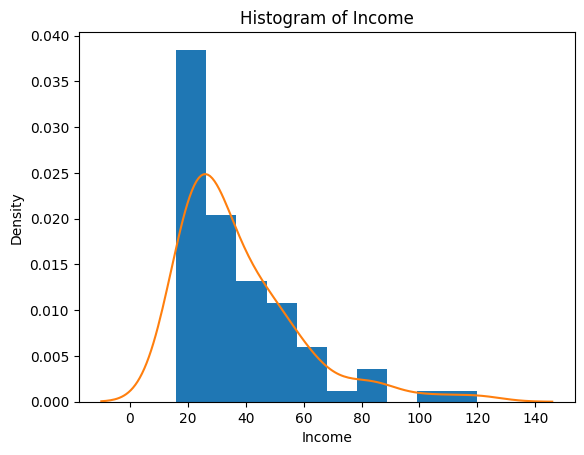

In [41]:
income = pd.read_csv('https://stat4ds.rwth-aachen.de/data/Income.dat', sep=r'\s+')
plt.hist(income['income'], density=True, bins='auto')
sns.kdeplot(income['income'])
plt.xlabel('Income')
plt.ylabel('Density')
plt.title('Histogram of Income')
plt.show()

`(b) Your answer goes here`

Bounded at 0 and right-skewedness: This distribution justifies exponential and gamma distribution families since income cannot be negative and the right-skewedness.

Density at 0: For exponential distributions, the highest density is always at x = 0 whereas density starts at 0 at x=0 for gamma distributions. The histogram shows income density is at 0 or near 0 at x=0 and rises to its peak at $20-$30k, this follows the shape of a gamma distribution. 

The most appropriate distribution family for this data is the gamma distribution due to the reasons above.

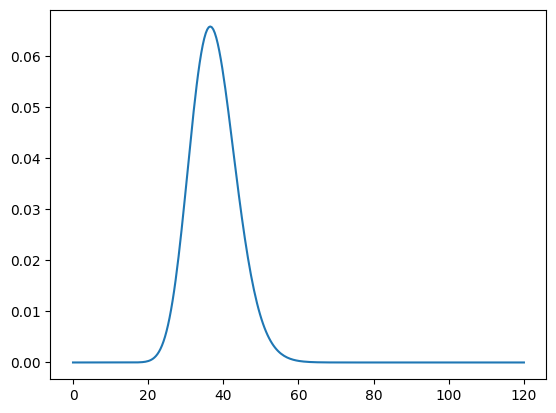

In [48]:
from scipy.stats import gamma

mean = income['income'].mean()
x = np.linspace(0, income['income'].max(), 300)
gamma_pdf = gamma.pdf(x, a=mean, scale=1)
plt.plot(x, gamma_pdf)
plt.show()


## Problem # 2.21.

Plot the gamma distribution by fixing the shape parameter *k* = 3 and setting the scale parameter
= 0.5, 1, 2, 3, 4, 5. What is the effect of increasing the scale parameter? (See also Exercise 2.48.)

`Your answer goes here`

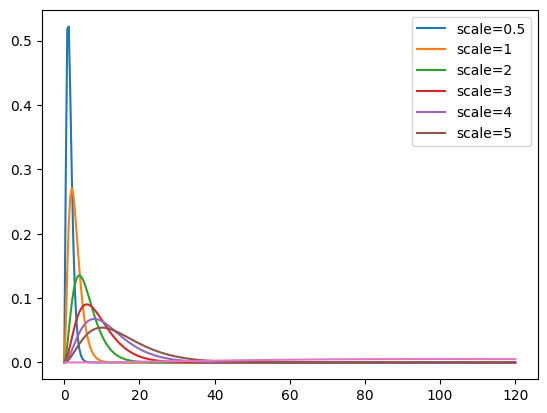

In [43]:
from scipy.stats import gamma

plt.plot(x, gamma.pdf(x, a=3, scale=.5))
plt.plot(x, gamma.pdf(x, a=3, scale=1))
plt.plot(x, gamma.pdf(x, a=3, scale=2))
plt.plot(x, gamma.pdf(x, a=3, scale=3))
plt.plot(x, gamma.pdf(x, a=3, scale=4))
plt.plot(x, gamma.pdf(x, a=3, scale=5))
plt.plot(x, gamma.pdf(x, a=3, scale=50))

plt.legend(['scale=0.5', 'scale=1', 'scale=2', 'scale=3', 'scale=4', 'scale=5'])
plt.show()

As The Scale Parameter Increases: as scale increases, the shape becomes flatter due to noise whereas a smaller scale parameter makes the shape have a higher peak.

## Problem # 2.22.

Consider the mammogram diagnostic example in Section 2.1.4.

(a) Show that the joint probability distribution of diagnosis and disease status is as shown in
Table 2.6. Given that a diagnostic test result is positive, explain how this joint distribution
shows that the 12% of incorrect diagnoses for the 99% of women not having breast cancer
swamp the 86% of correct diagnoses for the 1% of women actually having breast cancer.

(b) The first test for detecting HIV-positive status had a sensitivity of 0.999 and specificity
of 0.9999. Explain what these mean. If at that time 1 in 10,000 men were truly HIV-positive,
find the positive predictive value. Based on this example, explain the potential disadvantage
of routine diagnostic screening of a population for a rare disease.

**Table 2.6.** Joint probability distribution for disease status and diagnosis of breast-cancer
mammogram, based on conditional probabilities in Table 2.1.

$$
\begin{array}{lccc}
\textbf{Disease Status} & \textbf{Positive (+)} & \textbf{Negative (–)} & \textbf{Total} \\
\hline
\text{Yes }(D) & 0.0086 & 0.0014 & 0.01 \\
\text{No }(D^c) & 0.1188 & 0.8712 & 0.99 \\
\hline
\end{array}
$$

`(a) Your answer goes here`

False-Positives Outnumber True-Positives: The table shows that ~12% (11.88%) of the women who did not have the disease (99% of the total population) received a positive diagnosis for it and .86% (.0086) of women who have the disease (1% of the total population) and tested positive for it. 

If we do a simulation of this:

num_subjects = 10,000
true_positive = num_subjects x .99 = 9,900
false_positive = num_subjects x .01 = 100

12% of the true_positive = 9,900 x .12 = 1,188
86% of the false_positive = 100 x .86 = 86

We can see that the number of true-positives (86) is much lower than the number of false-positives (1,188). This is because a bigger percentage of a smaller number is still a smaller number.

`(b) answer here`

Sensitivity: This is the true-positive rate. P(Positive | Disease), the probability of a person receiving a positive test result given that they also have the disease. In this case the sensitivity rating of .999 shows that of the people that have the disease, 99.9% of them will test positive.

Specificity: This is the true-negative rate. P(Negative | No Disease), the probability of a person receiving a negative test result given that they don't have the disease. In this case the specificity rating of .9999 shows that of the people who do not have the disease, 99.99% will test negative.

Used Claude here to help with application of Bayes Theorem

PPV = P(Disease | Positive)

P(Disease) = 1/10,000 = .0001

P(No Disease) = .9999

P(Positive | Disease) = .999

P(Positive | No Disease) = 1 - P(Negative | No Disease) = 1 - .9999 = .0001

P(Positive) = P(Positive | Disease) * P(Disease) + P(Positive | No Disease) * P(No Disease) = (.999 * .0001) + (.0001 * .9999)

P(Disease | Positive) = P(Positive | Disease) * P(Disease) / P(Positive) = .999 * .0001 / .00019998 = .48

The PPV is .48 meaning that after receiving a positive test result, there's a ~50% chance that you have the disease or a ~50% chance that you don't have the disease. To answer the last part of this question, this routine screening for rare diseases produces large numbers of false positives even with a very accurate test leading to unnecessary resource spending to find out if the test was correct or not.

## Problem # 2.27.

The distribution of *X* = heights *(cm)* of women in the U.K. is approximately *N*(162, $7^2$).
Conditional on *X = x*, suppose *Y* = weight *(kg)* has a *N*(3.0 + 0.40x, $8^2$) distribution. Simulate
and plot 1000 observations from this approximate bivariate normal distribution. Approximate
the marginal means and standard deviations for *X* and *Y*. Approximate and interpret the
correlation.


`Your answer goes here`

mu = 162
sd = 7
var = 7**2

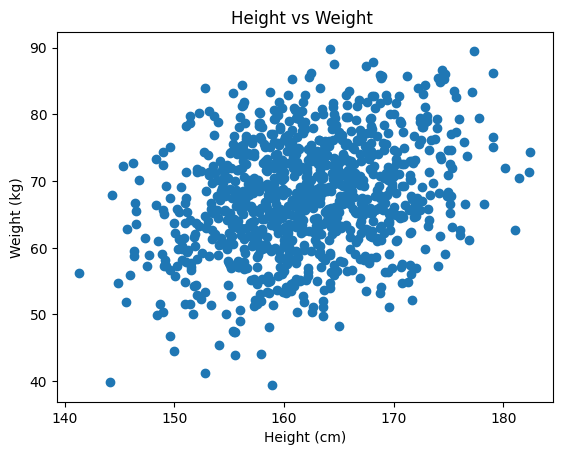

Average Height =  161.95776091075246
Height standard deviation =  6.912156351192841
Average Weight =  67.53799476831489
Weight standard deviation =  8.409746934332903
Correlation between Height and Weight =  [[1.         0.29816244]
 [0.29816244 1.        ]]


In [44]:
from scipy.stats import norm

X = norm.rvs(size = 1000, loc = 162, scale = 7)
Y = norm.rvs(size = 1000, loc = [3 + 0.4*x for x in X], scale = 8)

plt.scatter(X, Y)
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Height vs Weight ')
plt.show()

print('Average Height = ', X.mean())
print('Height standard deviation = ', X.std())
print('Average Weight = ', Y.mean())
print('Weight standard deviation = ', Y.std())

print('Correlation between Height and Weight = ', np.corrcoef(X, Y))

I asked Claude to help structure the interpretation

Correlation: The correlation is .34 which is positive and moderate. Positive makes sense since Y's mean increases as X increase (3 + .4x) and moderate because of the variance adding independent noise (var = 8**2).

## Bayes’ Theorem and AI Decision Reliability

An autonomous drone uses an onboard AI to detect whether an area contains a **target object** (for example, a missing person wearing a bright jacket).  
The system raises an alert when it believes a target is present. However, the model is not perfect.

- $P(\text{Target}) = 0.03$
- $P(\text{Alert} \mid \text{Target}) = 0.95$
- $P(\text{Alert} \mid \text{No Target}) = 0.10$

### Tasks

1. **Compute the probability of an alert**

   Use the law of total probability:
   $$P(\text{Alert}) = P(\text{Alert} \mid \text{Target})P(\text{Target}) + P(\text{Alert} \mid \text{No Target})P(\text{No Target})$$

2. **Compute the posterior probability**

   Apply Bayes’ theorem.

$$P(\text{Target} \mid \text{Alert}) =
\frac{P(\text{Alert} \mid \text{Target})P(\text{Target})}{P(\text{Alert})}$$



3. **Implement in Python**

   Write a short script that calculates and prints both probabilities with clear labels.

4. **Interpret your result**

   In a short paragraph (as a code comment), explain what your computed $(P(\text{Target} \mid \text{Alert})$ means about the AI's reliability when it triggers an alert.

5. **Bonus**

   Create a function that allows a user to change:
   - $P(\text{Target})$
   - $P(\text{Alert} \mid \text{Target})$
   - $P(\text{Alert} \mid \text{No Target})$

   Then return the updated posterior probability and show how the result changes when $P(\text{Target}) = 0.005$.

### Starter Code

In [45]:
## Bayes' Theorem in AI Detection Reliability

############################# Given probabilities ##############################
P_target = 0.03
P_alert_given_target = 0.95
P_alert_given_no_target = 0.10
################################################################################
# Compute complements
P_no_target = 1 - P_target

# 1. Total probability of alert
P_alert = (P_alert_given_target * P_target) + (P_alert_given_no_target * P_no_target)

# 2. Posterior probability using Bayes' theorem
P_target_given_alert = (P_alert_given_target * P_target) / P_alert

print(f"P(Alert): {P_alert:.4f}")
print(f"P(Target | Alert): {P_target_given_alert:.4f}")

"""
Interpretation:
When the AI raises an alert, this tells us how likely it is that
a target is actually present. A low posterior means many false alarms.
"""

# Bonus: parameterized function
def bayes_posterior(P_target, P_alert_given_target, P_alert_given_no_target):
    P_no_target = 1 - P_target
    P_alert = (P_alert_given_target * P_target) + (P_alert_given_no_target * P_no_target)
    return (P_alert_given_target * P_target) / P_alert

print("Posterior with P(Target)=0.005:",
      bayes_posterior(0.005, 0.95, 0.10))


P(Alert): 0.1255
P(Target | Alert): 0.2271
Posterior with P(Target)=0.005: 0.04556354916067146


Posterior Probability = ~.05 tells us that the probability of an alert actually having the target object in the area is only ~5%.